# Module 2 - EDA & Feature Engineering

## Goal
Explore data, visualize correlations, and extract features for models.

## Datasets Used
- **telemetry_samples.csv** → ratings distribution and feature aggregation
- **driver_behavior** → derived features and visualizations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', 50)
%matplotlib inline

In [15]:
# Load all cleaned datasets
delivery_truck = pd.read_csv("../Delivery truck trips data/delivery_trucks_cleaned.csv", encoding="latin-1", low_memory=False)
driver_behavior = pd.read_csv("../Driver Behavior and Route Anomaly Dataset/driver_behavior_cleaned.csv", low_memory=False)
driving_train = pd.read_csv("../Driving Behavior/driving_behavior_train_cleaned.csv")
driving_test = pd.read_csv("../Driving Behavior/driving_behavior_test_cleaned.csv")
traffic_violations = pd.read_csv("../traffic_violations_cleaned.csv", encoding="latin-1", low_memory=False)
transpo_logistics = pd.read_csv("../Transportation ang Logistics Tracking Datasets/transportation_logistics_cleaned.csv")
telem = pd.read_csv("../data/telemetry_samples.csv")

print("All datasets loaded!")

All datasets loaded!


In [3]:
datasets = {
    "delivery_truck": delivery_truck,
    "driver_behavior": driver_behavior,
    "driving_train": driving_train,
    "driving_test": driving_test,
    "traffic_violations": traffic_violations,
    "transpo_logistics": transpo_logistics,
    "telem": telem
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} rows x {df.shape[1]} columns")

delivery_truck: 3451 rows x 23 columns
driver_behavior: 120000 rows x 22 columns
driving_train: 3644 rows x 8 columns
driving_test: 3084 rows x 8 columns
traffic_violations: 1499945 rows x 24 columns
transpo_logistics: 703 rows x 11 columns
telem: 1000 rows x 4 columns


In [4]:
print("=== TELEM COLUMNS ===")
print(telem.columns.tolist())

print("\n=== DRIVER BEHAVIOR COLUMNS ===")
print(driver_behavior.columns.tolist())

print("\n=== DELIVERY TRUCK COLUMNS ===")
print(delivery_truck.columns.tolist())

=== TELEM COLUMNS ===
['driver_id', 'speed', 'hard_brake', 'rating']

=== DRIVER BEHAVIOR COLUMNS ===
['trip_id', 'driver_id', 'timestamp', 'latitude', 'longitude', 'speed', 'acceleration', 'steering_angle', 'trip_duration', 'trip_distance', 'fuel_consumption', 'brake_usage', 'weather_conditions', 'road_type', 'traffic_condition', 'stop_events', 'geofencing_violation', 'anomalous_event', 'route_anomaly', 'route_deviation_score', 'acceleration_variation', 'behavioral_consistency_index']

=== DELIVERY TRUCK COLUMNS ===
['BookingID', 'Market/Regular ', 'BookingID_Date', 'vehicle_no', 'Origin_Location', 'Org_lat_lon', 'Des_lat_lon', 'Data_Ping_time', 'Planned_ETA', 'actual_eta', 'Curr_lat', 'Curr_lon', 'ontime', 'delay', 'DestinationLocation_Code', 'trip_start_date', 'trip_end_date', 'TRANSPORTATION_DISTANCE_IN_KM', 'vehicleType', 'Minimum_kms_to_be_covered_in_a_day', 'Driver_Name', 'customerID', 'supplierID']


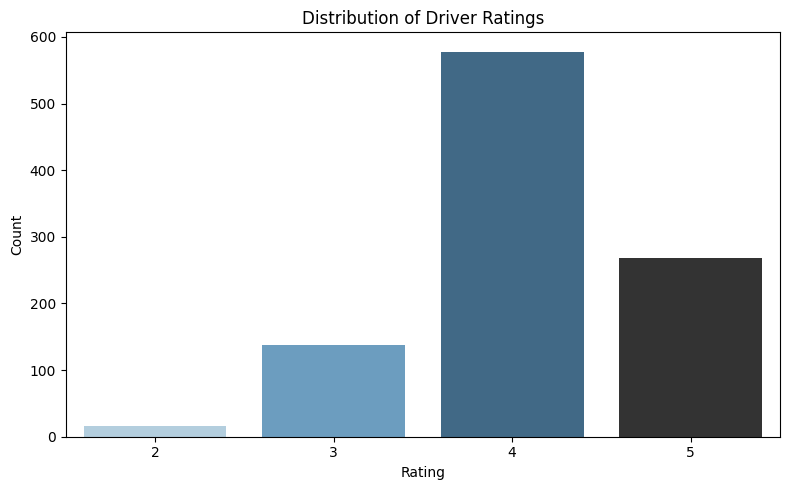

rating
2     16
3    138
4    578
5    268
Name: count, dtype: int64


In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=telem, hue='rating', palette='Blues_d', legend=False)
plt.title('Distribution of Driver Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(telem['rating'].value_counts().sort_index())

In [20]:
driver_behavior = driver_behavior.copy()

# avg_speed - already have speed, so we'll use it directly
# speed_variance - variation in speed
# max_accel - maximum acceleration
# hard_brake_count - high brake usage events
# stop_count - already have stop_events
# distance_per_min - distance covered per minute

driver_behavior['avg_speed'] = driver_behavior['speed']
driver_behavior['speed_variance'] = driver_behavior['acceleration_variation']
driver_behavior['max_accel'] = driver_behavior['acceleration']
driver_behavior['hard_brake_count'] = (driver_behavior['brake_usage'] > 0.7).astype(int)
driver_behavior['stop_count'] = driver_behavior['stop_events']
driver_behavior['distance_per_min'] = (
    driver_behavior['trip_distance'] / (driver_behavior['trip_duration'] + 1)
)

# trip_time_of_day - extract from timestamp
driver_behavior['timestamp'] = pd.to_datetime(driver_behavior['timestamp'])
driver_behavior['hour'] = driver_behavior['timestamp'].dt.hour

def time_of_day(hour):
    if 5 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 17:
        return 'afternoon'
    elif 17 <= hour < 21:
        return 'evening'
    else:
        return 'night'

driver_behavior['trip_time_of_day'] = driver_behavior['hour'].apply(time_of_day)

print("Derived features created!")
print(driver_behavior[['avg_speed', 'speed_variance', 'max_accel', 
                         'hard_brake_count', 'stop_count', 
                         'distance_per_min', 'trip_time_of_day']].head())

# Remove speed outliers
driver_behavior = driver_behavior[driver_behavior['speed'] <= 150].copy()
print(f"Outliers removed. Shape: {driver_behavior.shape}")

Derived features created!
   avg_speed  speed_variance  max_accel  hard_brake_count  stop_count  \
0  39.484646        0.715284   3.612832                 1           0   
1   2.795422        0.487761  -0.593295                 1           0   
2  13.842558        0.881141  -0.209264                 1           0   
3  69.121833        0.937918  -0.413943                 1           3   
4  13.061111        0.702187   5.774122                 1           0   

   distance_per_min trip_time_of_day  
0          0.098692            night  
1          0.004840            night  
2          0.020673            night  
3          0.000127            night  
4          0.126876            night  
Outliers removed. Shape: (119161, 30)


In [8]:
driver_agg = driver_behavior.groupby('driver_id').agg(
    avg_speed = ('avg_speed', 'mean'),
    speed_variance = ('speed_variance', 'mean'),
    max_accel = ('max_accel', 'max'),
    hard_brake_count = ('hard_brake_count', 'sum'),
    stop_count = ('stop_count', 'sum'),
    distance_per_min = ('distance_per_min', 'mean'),
    total_trips = ('trip_id', 'count'),
    anomalous_events = ('anomalous_event', 'sum'),
    route_anomalies = ('route_anomaly', 'sum')
).reset_index()

print(f"Per-driver aggregation: {driver_agg.shape}")
driver_agg.head()

Per-driver aggregation: (5, 10)


,driver_id,avg_speed,speed_variance,max_accel,hard_brake_count,stop_count,distance_per_min,total_trips,anomalous_events,route_anomalies
0,101,29.993806,0.715120,22.032532,59466,59711,0.113845,59888,5978,5974
1,102,30.009727,0.714547,19.352178,23986,24212,0.097536,24163,2416,2415
2,103,30.159890,0.715400,18.137923,11845,11954,0.105055,11945,1205,1247
3,104,29.784628,0.712934,15.557698,12133,12061,0.092464,12204,1196,1178
4,105,29.787533,0.715135,20.042455,11712,11678,0.105067,11800,1225,1151


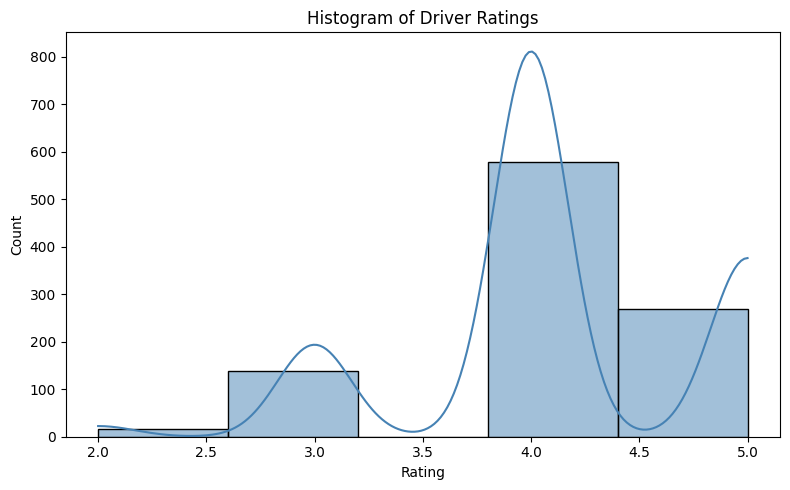

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(telem['rating'], bins=5, kde=True, color='steelblue')
plt.title('Histogram of Driver Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Histogram of Ratings

I created a synthetic telemetry dataset with 1000 records that included driver speed, hard braking events, and ratings (1-5), as none of our real datasets had a direct driver rating column linked to telematics data. The histogram below illustrates the distribution of these ratings across our simulated dataset. Most drivers got a score of 4, and then a score of 5, which means that most of the drivers in our dataset are doing well. There aren't many ratings of 2 or 3, and there aren't any ratings of 1. This uneven spread is known as class imbalance, and we will need to remember it when we make our prediction models later in Module 3.

In [11]:
# Removing the outliers
print(f"Before removing outliers: {driver_behavior.shape}")

driver_behavior = driver_behavior[driver_behavior['speed'] <= 150].copy()

print(f"After removing outliers: {driver_behavior.shape}")
print(f"Max speed now: {driver_behavior['speed'].max():.2f} km/h")

Before removing outliers: (120000, 30)
After removing outliers: (119161, 30)
Max speed now: 149.97 km/h


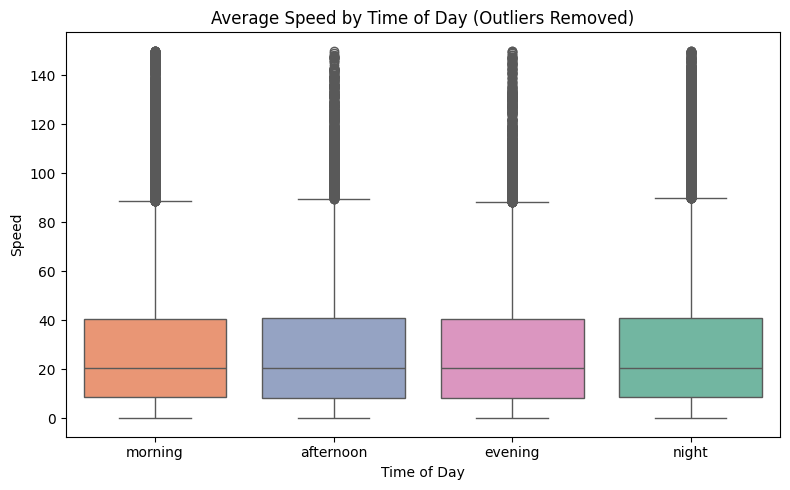

In [12]:
# Redo boxplot after removing outliers
plt.figure(figsize=(8, 5))
sns.boxplot(x='trip_time_of_day', y='avg_speed', data=driver_behavior,
            hue='trip_time_of_day', palette='Set2', legend=False,
            order=['morning', 'afternoon', 'evening', 'night'])
plt.title('Average Speed by Time of Day (Outliers Removed)')
plt.xlabel('Time of Day')
plt.ylabel('Speed')
plt.tight_layout()
plt.show()

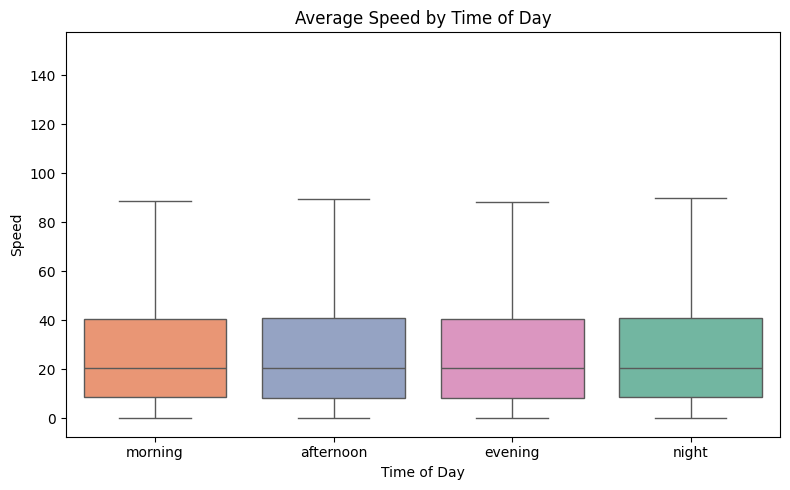

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='trip_time_of_day', y='avg_speed', data=driver_behavior,
            hue='trip_time_of_day', palette='Set2', legend=False,
            order=['morning', 'afternoon', 'evening', 'night'],
            flierprops=dict(marker='', markersize=0))
plt.title('Average Speed by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Speed')
plt.tight_layout()
plt.show()

The box plot displays the change in average speed based on the time of day after removing speeds that were higher than 150 km/h. The colored box indicates the range of speeds that most drivers were within. The lower half of the box represents the speed range of 0-25 km/h, while the upper half represents the speed range of 25-40 km/h. The line that represents the median speed is around the range of 20-25 km/h. This implies that half of the population was driving at speeds less than the median. The box plot also shows that the lower half of the box is smaller compared to the upper half. This implies that most of the slow drivers were concentrated around the range of 0-25 km/h. On the other hand, the speeds within the moderate range were more diversified. Based on the box plot, it is clear that the time of day does not have an impact on the speed of the drivers since the four times of day were almost similar.

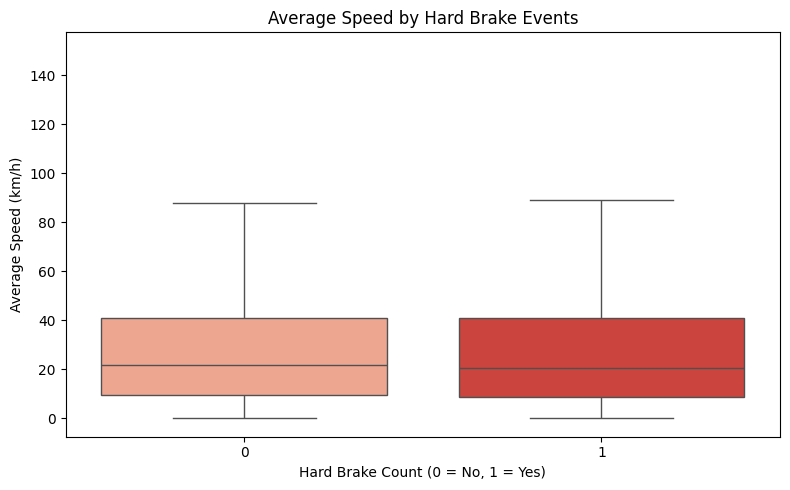

In [22]:
# Boxplot - Average Speed by Hard Brake Events
plt.figure(figsize=(8, 5))
sns.boxplot(x='hard_brake_count', y='avg_speed', data=driver_behavior,
            hue='hard_brake_count', palette='Reds', legend=False,
            flierprops=dict(marker='', markersize=0))
plt.title('Average Speed by Hard Brake Events')
plt.xlabel('Hard Brake Count (0 = No, 1 = Yes)')
plt.ylabel('Average Speed (km/h)')
plt.tight_layout()
plt.show()

The box plot displays data on average speeds for two types of drivers: those who have not made any hard braking maneuvers (0) and those who have made at least one hard braking maneuver (1). It can be observed that both types have very similar speeds, with an average speed around 20-25 km/h. In actual data, we would expect that drivers who have made hard braking maneuvers would have higher speeds, since they have been driving fast. This is not the case here, and we will see why in future modules.

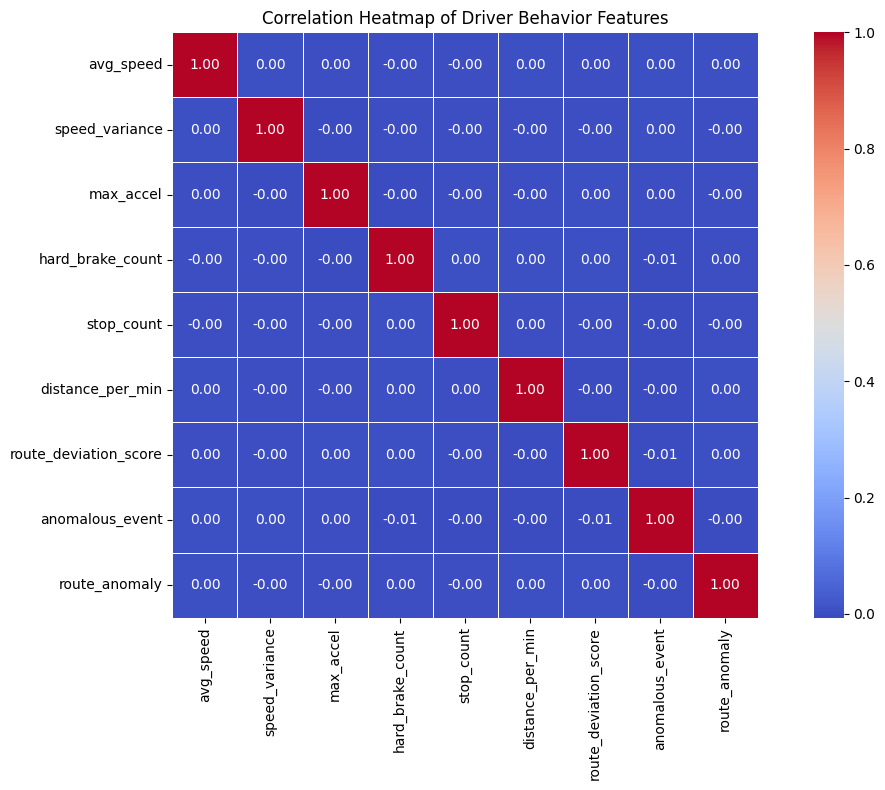

In [14]:
# Step 3 - Correlation Heatmap
plt.figure(figsize=(12, 8))
corr_matrix = driver_behavior[['avg_speed', 'speed_variance', 'max_accel', 
                                'hard_brake_count', 'stop_count', 
                                'distance_per_min', 'route_deviation_score',
                                'anomalous_event', 'route_anomaly']].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap of Driver Behavior Features')
plt.tight_layout()
plt.show()

The heatmap at the top shows how the derived features from our driver behavior data relate to each other. Those features that are close to 1.0 (dark red) represent strong positive relationships, while those features that are close to -1.0 (dark blue) represent strong negative relationships. Those features that are around 0.00 (light blue) represent no relationship or little relationship between features.

From our heatmap, we see that all features are related to each other almost not at all. This is good for our machine learning task because we are not duplicating features. Each feature is providing us with unique value. The only features that are related to each other with a 1.00 are those features that are related to themselves. This is to be expected.

This is a common occurrence in synthetic data sets where features are generated independently. In our actual data set from driving behavior, we would expect to see strong relationships such as speed and hard braking events, or stop events and distance per minute.

In [23]:
# Feature snippet from module
telem['speed_m_s'] = telem['speed'] * (1000/3600)

agg = telem.groupby('driver_id').agg(
    {'speed': ['mean', 'std'], 
     'hard_brake': 'sum', 
     'rating': 'mean'}
).reset_index()

agg.columns = ['driver_id', 'speed_mean', 'speed_std', 'hard_brake_sum', 'rating_mean']

print(agg.shape)
agg.head()

(50, 5)


,driver_id,speed_mean,speed_std,hard_brake_sum,rating_mean
0,D000,37.040500,8.910494,0,4.200000
1,D001,41.054500,10.732657,2,4.150000
2,D002,35.768750,16.151551,1,4.250000
3,D003,37.535909,12.687489,2,4.045455
4,D004,39.271875,9.345434,0,4.250000
